In [13]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
DATA_DIR = Path.cwd().parent / "data"

In [15]:
df_portfolio = pd.read_json(DATA_DIR / "portfolio.json", orient="records", lines=True)
df_profile = pd.read_json(DATA_DIR / "profile.json", orient="records", lines=True)
df_transcript = pd.read_json(DATA_DIR / "transcript.json", orient="records", lines=True)

# Portfolio dataset

In [26]:
df_portfolio

,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"[web, email, mobile, social]",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"[web, email, mobile, social]",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"[email, mobile, social]",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"[web, email, mobile, social]",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"[web, email, mobile]",10,7,discount,2906b810c7d4411798c6938adc9daaa5


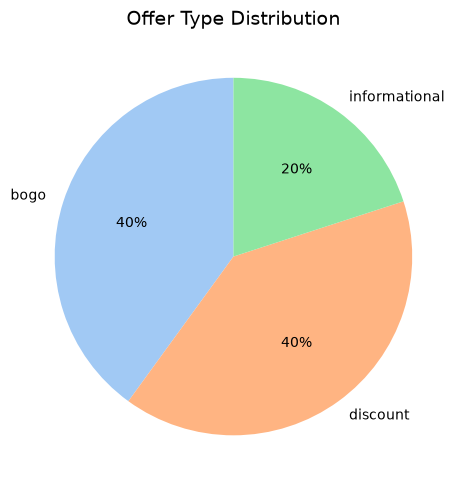

In [82]:
offer_counts = df_portfolio["offer_type"].value_counts().reset_index()
offer_counts.columns = ["Offer Type", "Count"]

plt.figure(figsize=(8, 5))

plt.pie(offer_counts["Count"], labels=offer_counts["Offer Type"], startangle=90, autopct="%1.0f%%", colors=sns.color_palette("pastel"))

plt.title("Offer Type Distribution", fontsize=14)

plt.tight_layout()
plt.show()

# Profile dataset

In [28]:
df_profile.head()

,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [43]:
df_profile.isna().sum()

gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

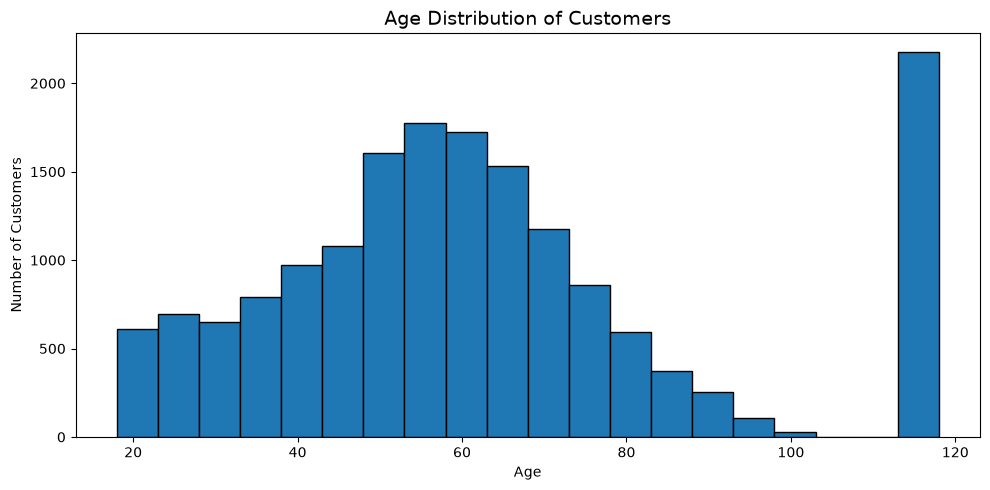

In [72]:
df_profile['age'].hist(bins=20, edgecolor='black', figsize=(10, 5))
plt.title('Age Distribution of Customers', fontsize=14)

plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.grid(False)
plt.tight_layout()
plt.show()


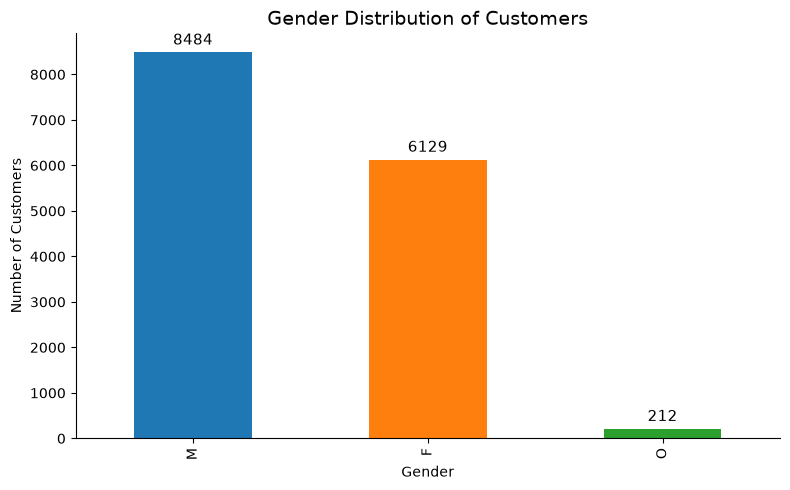

In [42]:
ax = df_profile['gender'].value_counts().plot(kind='bar', figsize=(8, 5), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11)

plt.title('Gender Distribution of Customers', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

sns.despine()
plt.tight_layout()
plt.show()


# Transcript dataset

In [44]:
df_transcript.head()

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [50]:
df_transcript.isna().sum()

person    0
event     0
value     0
time      0
dtype: int64

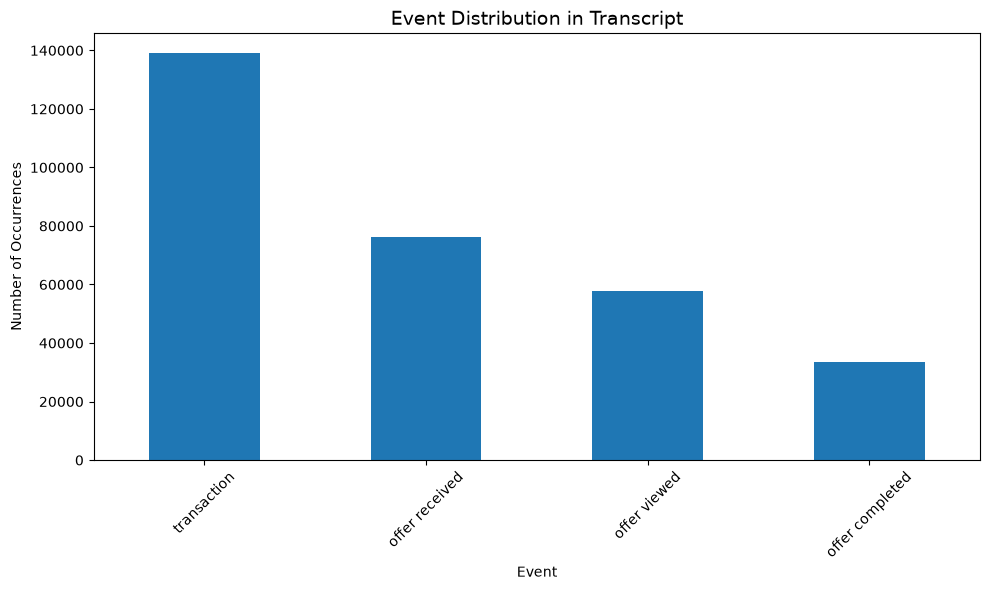

In [49]:
ax = df_transcript['event'].value_counts().plot(kind='bar', figsize=(10, 6))

plt.title('Event Distribution in Transcript', fontsize=14)
plt.xlabel('Event')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [68]:
df_transcript["value_key"] = df_transcript["value"].apply(lambda x: next(iter(x)))
df_transcript["value_offer"] = df_transcript["value"].apply(lambda x: next(iter(x.values())))

event_value_matrix = pd.crosstab(df_transcript["event"], df_transcript["value_key"])
event_value_matrix

value_key,amount,offer id,offer_id
event,,,
offer completed,0,0,33579
offer received,0,76277,0
offer viewed,0,57725,0
transaction,138953,0,0


In [71]:
print('Event distribution in case of informational offer:')
print(df_transcript[df_transcript["value_offer"] == '3f207df678b143eea3cee63160fa8bed']['event'].value_counts().sort_values(ascending=False))
print('\nEvent distribution in case of discount offer:')
print(df_transcript[df_transcript["value_offer"] == '0b1e1539f2cc45b7b9fa7c272da2e1d7']['event'].value_counts().sort_values(ascending=False))

print('\nEvent distribution in case of BOGO offer:')
print(df_transcript[df_transcript["value_offer"] == 'ae264e3637204a6fb9bb56bc8210ddfd']['event'].value_counts().sort_values(ascending=False))

Event distribution in case of informational offer:
event
offer received    7617
offer viewed      4144
Name: count, dtype: int64

Event distribution in case of discount offer:
event
offer received     7668
offer completed    3420
offer viewed       2663
Name: count, dtype: int64

Event distribution in case of BOGO offer:
event
offer received     7658
offer viewed       6716
offer completed    3688
Name: count, dtype: int64


# Summary

After importing the three datasets, I checked the distribution of the features.

**Portfolio.** This dataset holds the metadata of the promotions. I found no missing values or outliers. It contains three different promotion types with numerical parameters that will be useful in feature engineering and training. I also checked how the promotions are distributed.

**Profile.** This dataset holds the customer-level information. The `gender` and `income` columns are missing for exactly the same rows, which suggests a data collection issue rather than random missingness. I will treat the missing gender as its own category, and create a separate flag for the missing income, since the fact that it is missing carries information on its own. The `age` column has an outlier value with a suspiciously high frequency, which most likely encodes a missing age. This has to be handled as well.

**Transcript.** This dataset holds the event log, with four different event types. Checking the event types by promotion type, I found that informational offers only have `offer received` and `offer viewed` events — there is no `offer completed` event for them.

## Target variable

The most important step of feature engineering is building the `success` variable, which will be the binary target. Based on the original description, a promotion is successful in two different ways:

- **Informational offers:** the customer viewed the promotion and made a transaction within the validity window (the length comes from the portfolio dataset).
- **BOGO and discount offers:** the customer viewed the promotion and completed it as well.